# Interactive Prototype

Goal: Create a functional MVP for field route planning and management.

Stages:
1. Region Input & Sub-Division
2. Automatic Target Search & Routing
3. Manual Adjustment
4. Select & Execute Plans

## Region Input & Sub-Division

- Get region outline
- Divide into work cells
- Tentative plan for depot locations
- 

### Dummy Region Shapefile

At this point, we do not actually have a shapefile of the target region. The following two Jupyter cells will generate one using the outline of the orthophoto we have created. 

Load this as the "shapefile" which will define our working region. 

In [1]:
region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_contour_shapefile = '../input/interactive_proto/region_contour.shp'
region_contour_geojson = '../input/interactive_proto/region_contour.geojson'


region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations
simplification_tolerance = 5


In [2]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

### Create Voronoi Partitioning, Solve for Depots

- [x] Display region outline
- [x] Display region partition cells, centroids
- [x] Find and indicate depot locations
- [ ] Plan routes (pre-target adjustment CV) 

Possible Improvements:
- Manually place depots: have it reflect efficiency of placements
- What do we actually deliver to a client/NRCS to prove we did the routes?
    - Maybe ask Cade what he would like to see
- What would we need to change/update before handing this off to Cade?
- Builds into flight-tracking platform?
- How can we package this into something more user friendly?
- TODO: close loop on route waypoint file generation
- Is GPS accurate enough?

In [3]:
# Cell generation parameters
target_area_acres = 0.5
# target_area_acres = 1.5
# target_area_acres = 2.5

target_area_sqm = target_area_acres * 4046.86
max_iterations = 15 # Cycles to find improved partition
voronoi_partition_filename = '../input/interactive_proto/voronoi_partition.geojson'
voronoi_centroids_filename = '../input/interactive_proto/voronoi_centroids.geojson'

# Depot placement parameters
depot_radius = 225  # Max distance a depot can cover
grid_density = 4
depots_filename = '../input/interactive_proto/depot_points.geojson'


# Target detection parameters
binary_mask_path = "../outputs/region_binary_mask.tif"
region_orthophoto_filename = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
targets_plants_filename = '../input/interactive_proto/targets.geojson'

# Macro route planning parameters
t_max_distance = 850  # Max distance per trip (meters)
t_distance_slack = 50
t_distance_slack_penalty = 10_000
t_slack_routes = 5
t_num_vehicles = 25
macro_routes_filename = '../input/interactive_proto/macro_routes.geojson'


In [4]:
from plant_search.region_partition import centroidal_voronoi_tessellation
from macro_planning.depot_placement import find_depots, assign_cells_to_depot

region_outline_gdf = gpd.read_file(region_contour_shapefile)
simplified_polygon = region_outline_gdf.geometry.iloc[0]
num_cells = int(simplified_polygon.area / target_area_sqm) # How many cells to generate

# Divide region into voronoi cells
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_cells, max_iterations)

# Find depots to cover all cells
depots_gdf = find_depots(depot_radius, cell_gdf, region_outline_gdf, grid_density)
depots_gdf, cell_gdf = assign_cells_to_depot(depots_gdf, cell_gdf) # No update GDFs in place

# for depot_id, depot in updated_cell_gdf.iterrows():
#     print(f'{depot_id}: {depot["closest_depot"]}')

Reached maximum iterations without full convergence.


In [5]:
from macro_planning.depot_placement import create_cells_depots_df
from macro_planning.trip_routing import assign_targets_to_routes

cells_depots_df = create_cells_depots_df(depots_gdf, cell_gdf)
# cells_depots_df



## Data Generation & Calculation

### Static Data
What we will assume to be the same even across multiple visits or treatment sessions.
- `region_outline_gdf`: Where we are working
- `cells_gdf`: Cells dividing our working region
- `targets_gdf`: Plants in the working area to be treated


---

### Ephemeral Data
Data which may be frequently re-calculated as needed based on the working environment and requirements.
- `depots_gdf`: Depots across working region for launching/landing drones
- 

#### Relational Ephemeral Data
Data which relates two or more of the above data structures to find useful results. We should assume that these will be frequently re-calculated.
- `cells_depots_df`: Associates each cell of our region with a serving depot
- `cells_workloads_df`: Relative amount of work to treat all targets in a cell
- `targets_routing_df`: Associates each target with an enclosing parent cell
- 


---


### Find Targets

Testing multiple approaches:
1. From full-sized orthophoto
2. From downscaled orthophoto
3. From pre-computed binary mask

In [6]:
from plant_search.image_preprocess import correct_binary_mask, identify_targets
from plant_search.load_image import load_image
from plant_search.macro_planning import calculate_cell_workloads, targets_to_depots
import rasterio

# Approach 3: from full-sized orthophoto
image, transform, bounds, image_crs = load_image(region_orthophoto_filename)

with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    
full_binary_mask = correct_binary_mask(binary_mask, image.shape)
targets_gdf = identify_targets(full_binary_mask, transform)

# Associate each target with a parent cell
cell_gdf, targets_gdf = calculate_cell_workloads(cell_gdf, targets_gdf)
targets_gdf = targets_to_depots(cell_gdf, targets_gdf) # Associate each target w/ a depot

Image CRS - EPSG:32613


In [7]:
targets_gdf.dtypes

geometry          geometry
bounding_box        object
parent_cell_id     float64
closest_depot       object
dtype: object

In [8]:
from macro_planning.trip_routing import create_distance_matrix, solve_basic_vrp, routes_to_gdf
from macro_planning.visualize_routing import plot_vrp_solution
from pandas import concat

macro_routes_gdf_list = []

for depot_index in range(len(depots_gdf)):
    base_station_gdf = depots_gdf.iloc[[depot_index]]
    base_station_id = base_station_gdf.iloc[0]["depot_id"]
    station_cells_gdf = cell_gdf[cell_gdf["closest_depot"] == base_station_id].copy()
    
    compensate_for_targets = True
    t_distance_matrix = create_distance_matrix(station_cells_gdf, base_station_gdf, compensate_for_targets) # excluding intra-workload cost
    t_num_cells = len(t_distance_matrix)-1 # Number of stops

    target_data = {
        "core": {
            "distance_matrix": t_distance_matrix,
            "num_vehicles": t_num_vehicles,
            "depot_index": t_num_cells,
            "max_distance": t_max_distance,
            "distance_slack": t_distance_slack,
            "distance_slack_penalty": t_distance_slack_penalty,
            "slack_routes": t_slack_routes
        }
    }

    print_routes = False # Set to True to see individual route statistics
    target_routes = solve_basic_vrp(target_data, print_routes)



    if target_routes and isinstance(target_routes, list):
        # t_title = "Workload-Compensated Routes"
        # plot_vrp_solution(station_cells_gdf, t_distance_matrix, simplified_polygon, base_station_gdf, target_routes, t_title)
        depot_macro_routes_gdf = routes_to_gdf(station_cells_gdf, base_station_gdf, target_routes)
        macro_routes_gdf_list.append(depot_macro_routes_gdf)
    else:
        print("No solution found.")

macro_routes_gdf = gpd.GeoDataFrame(concat(macro_routes_gdf_list, ignore_index=True), crs=region_crs)

# print(macro_routes_gdf_list)
# macro_routes_gdf
# print(macro_routes_gdf.keys())
# print(len(target_routes))
# for route in target_routes:
#     print(route)


In [9]:
macro_routes_gdf

,geometry,route_id,route_depot,route_cells
0,"LINESTRING (634338.698 3347200.07, 634237.656 ...",depot_22_R0,depot_22,"[7, 5, 2, 3]"
1,"LINESTRING (634338.698 3347200.07, 634206.319 ...",depot_22_R1,depot_22,"[4, 6, 10]"
2,"LINESTRING (634338.698 3347200.07, 634309.614 ...",depot_22_R2,depot_22,"[21, 24, 22]"
3,"LINESTRING (634338.698 3347200.07, 634376.371 ...",depot_22_R3,depot_22,"[27, 31, 39]"
4,"LINESTRING (634338.698 3347200.07, 634371.509 ...",depot_22_R4,depot_22,"[29, 35, 37, 41]"
5,"LINESTRING (634338.698 3347200.07, 634257.853 ...",depot_22_R5,depot_22,"[14, 9, 17]"
6,"LINESTRING (634338.698 3347200.07, 634206.854 ...",depot_22_R6,depot_22,"[1, 0, 13]"
7,"LINESTRING (634338.698 3347200.07, 634448.865 ...",depot_22_R7,depot_22,"[40, 43, 38, 33]"
8,"LINESTRING (634338.698 3347200.07, 634264.998 ...",depot_22_R8,depot_22,"[11, 12, 18, 28]"
9,"LINESTRING (634338.698 3347200.07, 634335.017 ...",depot_22_R9,depot_22,"[23, 20, 32]"


In [9]:
import geopandas as gpd

def associate_targets_with_routes(targets_gdf, macro_routes_gdf):
    # Initialize a new column for route_id in targets_gdf
    targets_gdf["route_id"] = None

    # Iterate through the macro_routes_gdf rows
    for _, route_row in macro_routes_gdf.iterrows():
        route_id = route_row["route_id"]
        route_cells = route_row["route_cells"]
        
        # Update targets_gdf: Assign route_id to targets whose parent_cell_id is in route_cells
        targets_gdf.loc[targets_gdf["parent_cell_id"].isin(route_cells), "route_id"] = route_id

    return targets_gdf

routed_targets_gdf = associate_targets_with_routes(targets_gdf, macro_routes_gdf)
# routed_targets_gdf

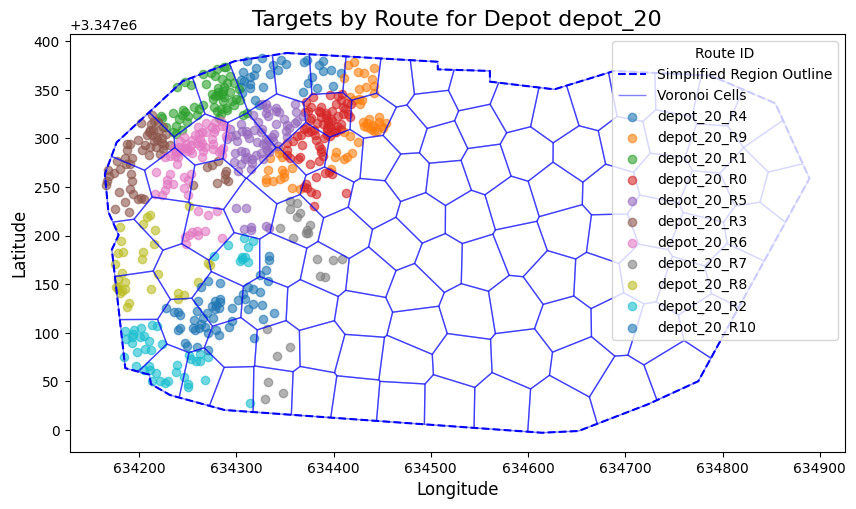

In [10]:
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_targets_by_route(targets_gdf, depot_id):
    """
    Plot all targets for a single depot, coloring targets by route_id.

    Parameters:
    - targets_gdf: GeoDataFrame
        GeoDataFrame containing target points with 'route_id' and 'parent_cell_id' columns.
    - depot_id: str
        The depot_id to filter and plot routes from.
    """
    # Filter targets for the given depot_id
    depot_targets = targets_gdf[targets_gdf['route_id'].str.startswith(depot_id)]
    
    # Get unique route_ids for the depot
    unique_routes = depot_targets['route_id'].unique()
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    region_outline_gdf.boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
    cell_gdf.boundary.plot(ax=ax, color="blue", linewidth=1, alpha=0.5, label="Voronoi Cells")  # Region cells
    # base_station_gdf.plot(ax=ax, color='red', markersize=80, marker='*', zorder=10, label='Base Station')
    
    # Plot targets for each route_id in a different color
    for route_id in unique_routes:
        route_targets = depot_targets[depot_targets['route_id'] == route_id]
        route_targets.plot(ax=ax, marker='o', label=route_id, alpha=0.6)
    
    # Set plot labels and legend
    ax.set_title(f"Targets by Route for Depot {depot_id}", fontsize=16)
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.legend(title="Route ID", fontsize=10, loc='best')
    plt.show()

# Example usage with dummy data
# Replace with real data as required

plot_depot_id = depots_gdf.iloc[0]['depot_id']
plot_targets_by_route(routed_targets_gdf, depot_id=plot_depot_id)  # Uncomment and replace with actual variables


In [11]:
from ortools.constraint_solver import pywrapcp, routing_enums_pb2
from shapely.geometry import Point

def calculate_tsp_route(route_targets_gdf, depot_point):
    """
    Calculate the TSP approximate shortest path for targets in a given route.

    Parameters:
    - route_targets_gdf: GeoDataFrame
        GeoDataFrame of targets for a specific route_id.
    - depot_point: shapely.geometry.Point
        Coordinates of the depot, used as the starting and ending point.

    Returns:
    - ordered_points: list of shapely.geometry.Point
        The ordered sequence of points representing the TSP route.
    - total_distance: float
        The total distance of the TSP route.
    """
    # Combine depot and targets into a single list of points
    points = [depot_point] + list(route_targets_gdf["geometry"])
    num_points = len(points)
    
    # Create distance matrix
    def distance_matrix():
        return [
            [points[i].distance(points[j]) for j in range(num_points)]
            for i in range(num_points)
        ]
    
    dist_matrix = distance_matrix()

    # Create the TSP solver
    manager = pywrapcp.RoutingIndexManager(len(dist_matrix), 1, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int(dist_matrix[from_node][to_node] * 1000)  # Scale for integer optimization

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Solve TSP
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    solution = routing.SolveWithParameters(search_parameters)

    if not solution:
        raise ValueError("No solution found for TSP!")

    # Extract the ordered sequence of points
    index = routing.Start(0)
    ordered_points = []
    while not routing.IsEnd(index):
        node_index = manager.IndexToNode(index)
        ordered_points.append(points[node_index])
        index = solution.Value(routing.NextVar(index))
    ordered_points.append(points[0])  # Return to depot

    # Calculate total distance
    total_distance = sum(
        ordered_points[i].distance(ordered_points[i + 1]) for i in range(len(ordered_points) - 1)
    )
    
    return ordered_points, total_distance


def calculate_all_routes_tsp(routed_targets_gdf, depot_point_gdf):
    """
    Calculate the TSP route for all targets grouped by route_id.
    
    Parameters:
    - targets_gdf: GeoDataFrame
        GeoDataFrame of all targets, including route_id and geometry.
    - macro_routes_gdf: GeoDataFrame
        GeoDataFrame of macro routes with route_id and associated route_cells.
    - depot_point: shapely.geometry.Point
        Coordinates of the depot, used as the starting and ending point.

    Returns:
    - results: dict
        Dictionary where keys are route_ids and values are (ordered_points, total_distance).
    """
    results = {}
    unique_route_ids = routed_targets_gdf["route_id"].unique()

    plot_depot_id = depot_point_gdf.iloc[0]['depot_id']
    route_targets_gdf = routed_targets_gdf[routed_targets_gdf['closest_depot'] == plot_depot_id]
    depot_point = depots_gdf.iloc[0]['geometry']

    for route_id in unique_route_ids:
        route_targets = route_targets_gdf[route_targets_gdf["route_id"] == route_id]
        if not route_targets.empty:
            ordered_points, total_distance = calculate_tsp_route(route_targets, depot_point)
            results[route_id] = {"ordered_points": ordered_points, "total_distance": total_distance}
    
    return results


In [12]:
# Mystery: why does the CRS sometimes change?
# routed_targets_gdf

In [13]:
depot_point_gdf = depots_gdf.iloc[[0]] # GDF of just one row

results = calculate_all_routes_tsp(routed_targets_gdf, depot_point_gdf)

# # Print results for each route
# for route_id, data in results.items():
#     print(f"Route ID: {route_id}")
#     print(f"Ordered Points: {data['ordered_points']}")
#     print(f"Total Distance: {data['total_distance']:.2f}")

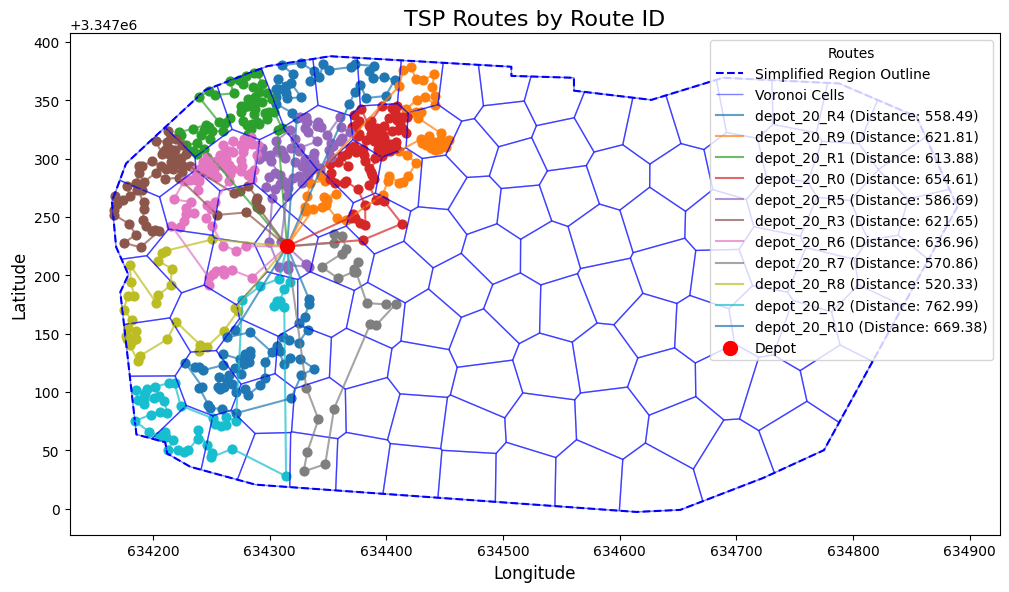

In [14]:
def plot_routes(results, depot_point, macro_routes_gdf):
    """
    Plot TSP routes for all route_ids associated with a depot.

    Parameters:
    - results: dict
        Dictionary of TSP results, where keys are route_ids and values are
        {'ordered_points': list of shapely.geometry.Point, 'total_distance': float}.
    - depot_point: shapely.geometry.Point
        Coordinates of the depot, plotted as a reference point.
    - macro_routes_gdf: GeoDataFrame
        GeoDataFrame containing route information for labeling.
    """
    # Set up the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    region_outline_gdf.boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
    cell_gdf.boundary.plot(ax=ax, color="blue", linewidth=1, alpha=0.5, label="Voronoi Cells")  # Region cells
    
    # Plot each route with a unique color
    for route_id, data in results.items():
        ordered_points = data['ordered_points']
        x_coords, y_coords = zip(*[(point.x, point.y) for point in ordered_points])
        
        # Plot the route as a line
        ax.plot(x_coords, y_coords, label=f"{route_id} (Distance: {data['total_distance']:.2f})", alpha=0.7)
        ax.scatter(x_coords, y_coords, s=40)  # Plot the points
        
    # Plot the depot
    ax.scatter(depot_point.x, depot_point.y, color='red', s=100, label='Depot', zorder=5)
    
    # Set plot labels and legend
    ax.set_title("TSP Routes by Route ID", fontsize=16)
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.legend(title="Routes", fontsize=10, loc='best')
    plt.show()

# Example usage with dummy data
# Replace with real data as required
depot_point = depots_gdf.iloc[0]['geometry']
plot_routes(results, depot_point, macro_routes_gdf)  # Uncomment and replace with actual variables


In [15]:
from shapely.geometry import LineString
import geopandas as gpd

def create_micro_routes_gdf(results, macro_routes_gdf, depot_point):
    """
    Create a GeoDataFrame of polylines for the solved micro routes.

    Parameters:
    - results: dict
        Dictionary of TSP results, where keys are route_ids and values are
        {'ordered_points': list of shapely.geometry.Point, 'total_distance': float}.
    - macro_routes_gdf: GeoDataFrame
        GeoDataFrame containing route information (e.g., route_cells, route_id).
    - depot_point: shapely.geometry.Point
        Coordinates of the depot.

    Returns:
    - routes_gdf: GeoDataFrame
        GeoDataFrame of polylines with columns for 'route_id', 'closest_depot', and 'route_cells'.
    """
    route_ids = []
    polylines = []
    closest_depots = []
    route_cells_list = []

    for route_id, data in results.items():
        ordered_points = data['ordered_points']
        route_line = LineString(ordered_points)  # Create a LineString from the ordered points

        # Get the corresponding row in macro_routes_gdf for additional attributes
        macro_route_row = macro_routes_gdf[macro_routes_gdf['route_id'] == route_id].iloc[0]
        route_cells = macro_route_row['route_cells']

        # Append data for the GeoDataFrame
        route_ids.append(route_id)
        polylines.append(route_line)
        closest_depots.append(depot_point)
        route_cells_list.append(route_cells)

    # Create the GeoDataFrame
    routes_gdf = gpd.GeoDataFrame({
        "route_id": route_ids,
        "geometry": polylines,
        "closest_depot": closest_depots,
        "route_cells": route_cells_list
    }, crs=macro_routes_gdf.crs)
    
    return routes_gdf

micro_routes_gdf = create_micro_routes_gdf(results, macro_routes_gdf, depot_point)
print(micro_routes_gdf)


        route_id                                           geometry  \
0    depot_20_R4  LINESTRING (634314.919 3347224.836, 634323.274...   
1    depot_20_R9  LINESTRING (634314.919 3347224.836, 634330.59 ...   
2    depot_20_R1  LINESTRING (634314.919 3347224.836, 634306.914...   
3    depot_20_R0  LINESTRING (634314.919 3347224.836, 634379.711...   
4    depot_20_R5  LINESTRING (634314.919 3347224.836, 634331.035...   
5    depot_20_R3  LINESTRING (634314.919 3347224.836, 634291.47 ...   
6    depot_20_R6  LINESTRING (634314.919 3347224.836, 634280.148...   
7    depot_20_R7  LINESTRING (634314.919 3347224.836, 634355.337...   
8    depot_20_R8  LINESTRING (634314.919 3347224.836, 634250.892...   
9    depot_20_R2  LINESTRING (634314.919 3347224.836, 634308.206...   
10  depot_20_R10  LINESTRING (634314.919 3347224.836, 634333.815...   

                                 closest_depot           route_cells  
0   POINT (634314.9194317985 3347224.83552811)          [22, 29, 43]  
1   P

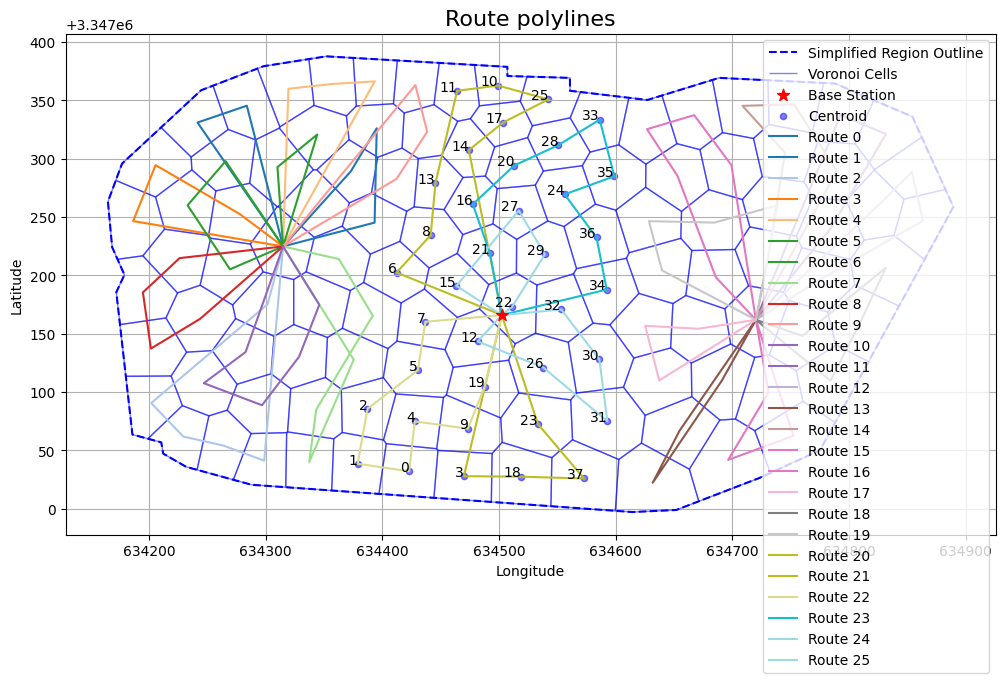

In [16]:
import math 
import matplotlib.pyplot as plt

base_station = base_station_gdf.geometry.iloc[0]  # Assuming single base station

# Plot centroids, region outline, and base station
fig, ax = plt.subplots(figsize=(12, 10))
region_outline_gdf.boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", linewidth=1, alpha=0.5, label="Voronoi Cells")  # Region cells
base_station_gdf.plot(ax=ax, color='red', markersize=80, marker='*', zorder=10, label='Base Station')

centroids = station_cells_gdf.cell_centroid
for i, centroid in enumerate(centroids):
    ax.scatter(centroid.x, centroid.y, color='blue', s=20, alpha=0.5, label='Centroid' if i == 0 else "")
    ax.text(centroid.x, centroid.y, str(i), fontsize=10, ha='right')

# Generate a colormap for routes
cmap = plt.get_cmap("tab20", len(macro_routes_gdf))  # Tab10 provides distinct colors
for route_idx, (index, row) in enumerate(macro_routes_gdf.iterrows()):
    ax.plot(*row.geometry.xy, color=cmap(route_idx), label=f"Route {index}")

ax.legend(loc="upper right", fontsize="small", title="Routes", ncol=2)

# Final plot details
ax.set_title("Route polylines", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc='upper right', fontsize=10)
plt.grid(True)
plt.show()

#### Write Data to Files


## GeoDataFrames Documentation

1. `cells_gdf`

**Description:**  
This GeoDataFrame represents a tessellation of the region, typically Voronoi cells or other partitioning polygons.

**Columns:**
- `geometry`: Polygon defining the spatial extent of each cell.
- `cell_centroid`: Centroid of the cell polygon.
- `cell_id`: Unique identifier for each cell.
- `target_count`: Number of target points within the cell (calculated via spatial join).
- `intra_workload`: Sum of Minimum Spanning Tree (MST) distances for targets within the cell (intra-cell workload).


2. `targets_gdf`

**Description:**  
This GeoDataFrame contains the spatial points representing the targets to be served or analyzed within the region.

**Columns:**
- `geometry`: Point geometry of each target.
- `parent_cell_id`: The ID of the cell that contains this target, assigned via spatial join.



3. `voronoi_gdf`

**Description:**  
This GeoDataFrame stores the Voronoi polygons clipped to the boundaries of a specified region.

**Columns:**
- `geometry`: Polygon geometry of each Voronoi cell.



4. `points_gdf`

**Description:**  
This GeoDataFrame stores the seed points used for generating Voronoi polygons.

**Columns:**
- `geometry`: Point geometry representing each seed point.

---



1. Region cells
2.  Region cell centroids
3. Depot locations

In [43]:
def print_gdf_info(gdf, name):
    print(f"GeoDataFrame: {name}")
    print("Columns and Types:")
    print(gdf.dtypes)
    print("-" * 40)

# Example usage
print_gdf_info(region_outline_gdf, "region_outline_gdf")
print_gdf_info(cell_gdf, "cells_gdf")
print_gdf_info(targets_gdf, "targets_gdf")
print_gdf_info(depots_gdf, "depots_gdf")
print_gdf_info(macro_routes_gdf, "macro_routes_gdf")
print_gdf_info(micro_routes_gdf, "micro_routes_gdf")

GeoDataFrame: region_outline_gdf
Columns and Types:
FID            int64
geometry    geometry
dtype: object
----------------------------------------
GeoDataFrame: cells_gdf
Columns and Types:
geometry             geometry
cell_centroid        geometry
cell_id                 int64
associated_depots      object
closest_depot          object
target_count            int64
intra_workload        float64
dtype: object
----------------------------------------
GeoDataFrame: targets_gdf
Columns and Types:
geometry          geometry
bounding_box        object
parent_cell_id     float64
closest_depot       object
route_id            object
dtype: object
----------------------------------------
GeoDataFrame: depots_gdf
Columns and Types:
geometry             geometry
depot_radius            int64
depot_id               object
min_enclosing_rad     float64
dtype: object
----------------------------------------
GeoDataFrame: macro_routes_gdf
Columns and Types:
geometry       geometry
route_id       

: 

In [17]:
cell_gdf_4326 = cell_gdf.copy().to_crs(visualization_crs)
# print(cell_gdf_4326.crs)

# Create a copy with only the 'geometry' column (Voronoi polygons)
voronoi_gdf = cell_gdf_4326.copy().drop(columns=["cell_centroid"])
voronoi_gdf.to_crs(visualization_crs, inplace=True)
voronoi_gdf.to_file(voronoi_partition_filename, driver="GeoJSON")

# Create a copy with only the 'cell_centroid' column and set it as the active geometry
centroid_gdf = cell_gdf_4326.copy().drop(columns=["geometry"])
centroid_gdf.set_geometry("cell_centroid", inplace=True)

centroid_gdf.set_crs(region_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_crs(visualization_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_file(voronoi_centroids_filename, driver="GeoJSON")

# Write Depot locations to file
depots_gdf.to_crs(visualization_crs, inplace=True)
depots_gdf.to_file(depots_filename, driver="GeoJSON")

# Write Targets locations to file
targets_gdf.to_crs(visualization_crs, inplace=True)
targets_gdf.to_file(targets_plants_filename, driver="GeoJSON")

# Write Macro-routes to file
macro_routes_gdf.to_crs(visualization_crs, inplace=True)
macro_routes_gdf.to_file(macro_routes_filename, driver="GeoJSON")

#### Data Interaction with Leaflet

In [18]:
from ipyleaflet import Circle, CircleMarker, LayerGroup

def create_depot_layers(depot_data):
    depot_layers = []

    for feature in depot_data["features"]:
        depot_plots = [] # Hold range, centerpoint circles
        coords = feature["geometry"]["coordinates"]
        properties = feature["properties"]
        depot_radius = properties.get("depot_radius", 0)  # Default to 0 if missing
        depot_id = properties.get("depot_id", "Unknown ID")
        depot_name = f'Depot {depot_id}'

        range_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=depot_radius,  # Circle radius in meters
            color='black', fill=False, fill_color='#3366cc',
            fill_opacity=0.05, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )
        
        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        depot_layergroup = LayerGroup(
            layers=(range_circle, center_circle),
            name=depot_name
        )
        depot_layers.append(depot_layergroup)
    
    return depot_layers

In [19]:
import geopandas as gpd
from ipyleaflet import (
    Map, GeoJSON, GeoData, Circle, LayerGroup,
    LayersControl, ScaleControl
)
from shapely.geometry import mapping, shape
import json

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi polygons
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load centroids
with open(voronoi_centroids_filename, "r") as f:
    centroid_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)

# print(region_contour_data)
print(voronoi_data)
# print(centroid_data)
# print(depot_data)




m = Map(center=(region_center.y, region_center.x), zoom=16)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'green', 'fillOpacity': 0.2, 'weight': 3},
    name=region_contour_data['name'])
m.add_layer(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
    name=voronoi_data['name'])
m.add_layer(voronoi_layer)

# Add centroids
centroid_layer = GeoJSON(
    data=centroid_data, 
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=centroid_data['name'])
centroid_layer.visible = False  # Set layer to hidden
m.add_layer(centroid_layer)

# Plot depot circles
depot_layers = create_depot_layers(depot_data)
for depot_layer in depot_layers:
    m.add(depot_layer)


m.add_control(LayersControl(position='topright'))
m.add(ScaleControl(position='bottomleft'))
m # Display the map

{'type': 'FeatureCollection', 'name': 'voronoi_partition', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'cell_id': 0, 'associated_depots': ['depot_20'], 'closest_depot': 'depot_20', 'target_count': 20, 'intra_workload': 142.44944984085393}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-103.60507749317401, 30.249604158386305], [-103.60500107844719, 30.249355070433747], [-103.60519683560435, 30.249151097754734], [-103.60542280732713, 30.249126582808973], [-103.60546976273096, 30.249221478768387], [-103.60550211222898, 30.24957322359244], [-103.60542957646238, 30.24973670493613], [-103.60507749317401, 30.249604158386305]]]}}, {'type': 'Feature', 'properties': {'cell_id': 1, 'associated_depots': ['depot_20'], 'closest_depot': 'depot_20', 'target_count': 9, 'intra_workload': 96.81593858406879}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-103.60519683560435, 30.249151097754734], [-103.60489216634

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Minimal Depot Interactions

In [20]:
def depot_selection_layers(depot_data, cell_data):
    depot_layers = {} # dict, where key is depot_id

    for feature in depot_data["features"]:
        depot_plots = [] # Hold range, centerpoint circles
        coords = feature["geometry"]["coordinates"]
        properties = feature["properties"]
        depot_radius = int(properties.get("depot_radius", 0))  # Default to 0 if missing
        min_encl_radius = int(properties.get("min_enclosing_rad", 0))  # Default to 0 if missing
        valid_depot_range = (depot_radius-min_encl_radius) if min_encl_radius>0 else 0

        depot_id = properties.get("depot_id", "Unknown ID")
        depot_name = f'Depot {depot_id}'

        # Find cells associated with each depot for coloration
        associated_cells = cell_data.copy()
        associated_cells['features'] = [feature for feature in cell_data['features']
                                        if feature['properties']['closest_depot'] == depot_id]

        # Add highlight to cells in depot range
        cells_layer = GeoJSON(
            data=associated_cells, 
            style={'color': 'red', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
            # style_callback=color_cells,
            name=associated_cells['name'])


        # Maximum range of depot
        range_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=depot_radius,  # Circle radius in meters
            color='black', fill=False, fill_color='#3366cc',
            fill_opacity=0.05, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        # Plot our minimum enclosing circle
        min_enclosing_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=min_encl_radius,  # Circle radius in meters
            color='green', fill=False, fill_color='#3366cc',
            fill_opacity=0.05, weight=1, opacity=0.15,
            tooltip=f"Depot ID: {depot_id}\nRadius: {min_encl_radius}m"
        )
        
        # All valid depot placements to cover all cells
        valid_depots_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=valid_depot_range,  # Circle radius in meters
            color='green', fill=True, fill_color='green',
            fill_opacity=0.1, weight=1, opacity=0.35,
            tooltip=f"Valid depot range: {depot_id}\nRadius: {valid_depot_range}m"
        )

        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        depot_layergroup = LayerGroup(
            layers=(cells_layer, range_circle, min_enclosing_circle, 
                    valid_depots_circle, center_circle),
            name=depot_name
        )
        depot_layers[depot_id] = depot_layergroup
    
    return depot_layers

In [21]:
from ipyleaflet import Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json


# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)



# Set up interactive layer selections
# ===================================
all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)

def on_depot_select(change):
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m2.substitute(old_layer, new_layer)

depot_select.observe(on_depot_select, names='value')




# Set up interactive map
# ======================
m2 = Map(center=(region_center.y, region_center.x), zoom=16, scroll_wheel_zoom=True)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m2.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m2.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m2.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m2.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m2.add(depot_layer)

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
m2.add(draw_control)

m2.add(FullScreenControl(position='topleft'))
m2.add(LayersControl(position='topright'))
m2.add(ScaleControl(position='bottomleft'))
m2

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [22]:
depot_data

list_depots = [feature['properties']['depot_id'] for feature in depot_data['features']]
print(list_depots)

['depot_20', 'depot_95', 'depot_145']


## Display Targets w/ Cell Depot

- Each identified target is to be associated with a cell.
- Each cell is associated with a closest serving depot.

In [23]:
from ipyleaflet import GeoJSON, LayerGroup, CircleMarker, AntPath

def macro_route_display_layers(depot_data, macro_routes_data):
    macro_route_layers = {}
    for depot_feature in depot_data["features"]:
        properties = depot_feature["properties"]
        depot_id = properties.get("depot_id", "Unknown ID")
        coords = depot_feature["geometry"]["coordinates"]


        associated_routes = macro_routes_data.copy()
        associated_routes['features'] = [feature for feature in macro_routes_data['features']
                                        if feature['properties']['route_depot'] == depot_id]

        routes_layer = GeoJSON(
            data=associated_routes, 
            style={'color': 'green', 'fillColor': 'green', 'opacity': 0.25, 'weight': 1},
            hover_style={'color': 'red' , 'opacity': 0.8, 'weight': 3},
            name=f'Depot ID: {depot_id} macro routes'
        )

        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        routes_layergroup = LayerGroup(
            layers=(routes_layer, center_circle),
            name=f"{depot_id} Routes"
        )
        macro_route_layers[depot_id] = routes_layergroup

    return macro_route_layers


def target_display_layers(depot_data, cell_data, targets_data):
    targets_layers = {}

    # 1) Associate each target with parent cell
    cell_targets = {} # dict, where key is depot_id
    for cell_feature in cell_data['features']:
        cell_properties = cell_feature['properties']
        cell_id = cell_properties.get("cell_id", "Unknown ID")

        # associated_targets = targets_data.copy()
        associated_targets = [feature for feature in targets_data['features']
                                        if feature['properties']['parent_cell_id'] == cell_id]
        cell_targets[cell_id] = associated_targets


    # 2) Associate each cell with depot
    depot_to_targets = {}
    for depot_feature in depot_data["features"]:
        properties = depot_feature["properties"]
        depot_id = properties.get("depot_id", "Unknown ID")
        coords = depot_feature["geometry"]["coordinates"]

        # Find cells associated with each depot for coloration
        associated_targets = targets_data.copy()
        associated_cell_ids = [feature['properties']['cell_id'] for feature in cell_data['features']
                                        if feature['properties']['closest_depot'] == depot_id]
        depot_targets = []
        for cell_id in associated_cell_ids:
            depot_targets += cell_targets[cell_id]
        associated_targets['features'] = depot_targets

        depot_to_targets[depot_id] = associated_targets

        # 3) Create targets layers

        # Display as Markers
        targets_layer = GeoJSON(
            data=associated_targets, 
            style={'color': 'red', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
            name=associated_targets['name'])
        
        # Display as Circle Marker points
        # targets_layer = GeoJSON(
        #     data=associated_targets,
        #     style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'fillOpacity':0.6},
        #     hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        #     point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        #     name=associated_targets['name']
        # )
        
        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )
        
        targets_layergroup = LayerGroup(
            layers=(targets_layer, center_circle),
            name=f"{depot_id} Targets"
        )
        targets_layers[depot_id] = targets_layergroup

    return targets_layers

In [24]:
from ipyleaflet import Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json
import time

# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)

with open(targets_plants_filename, "r") as f:
    targets_data = json.load(f)

with open(macro_routes_filename, "r") as f:
    macro_routes_data = json.load(f)

# Set up interactive layer selections
# ===================================
all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Targets associated with each depot
all_targets_layers = target_display_layers(depot_data, voronoi_data, targets_data)

# Routes associated with each depot
all_routes_layers = macro_route_display_layers(depot_data, macro_routes_data)

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)


def focus_depot_on_select(selected_depot_id):
    
    # Extract the selected depot's feature from depot_data
    selected_depot = next(
        feature for feature in depot_data['features'] if feature['properties']['depot_id'] == selected_depot_id
    )
    
    # Get the depot's center coordinates (assuming Point geometry)
    depot_lon, depot_lat = selected_depot['geometry']['coordinates']
    
    # Get depot range (example property, replace with actual if different)
    depot_range = selected_depot['properties'].get('min_enclosing_rad', 400)  # Default to 500m if not provided
    buffer = -3  # Add an extra buffer
    
    # Convert range + buffer to approximate degree offsets
    lat_offset = (depot_range + buffer) / 111000 # 111,000 meters per degree of latitude
    # lon_offset = lat_offset / abs(depot_lat / 360) # Adjust for longitude scaling at latitude
    lon_offset = lat_offset / math.cos(math.radians(depot_lat))

    # Calculate bounding box
    min_lat = depot_lat - lat_offset
    max_lat = depot_lat + lat_offset
    min_lon = depot_lon - lon_offset
    max_lon = depot_lon + lon_offset
    
    # Fit the map to the bounding box
    m3.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])


def on_depot_select(change):
    # Change depot display layers
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m3.substitute(old_layer, new_layer)
    time.sleep(0.1) # Race condition in layer replacement

    # Swap out our displayed targets
    old_targets = all_targets_layers[change['old']]
    new_targets = all_targets_layers[change['new']]
    m3.substitute(old_targets, new_targets)
    time.sleep(0.1) # Race condition in layer replacement

    # Swap out our displayed routes
    old_routes = all_routes_layers[change['old']]
    new_routes = all_routes_layers[change['new']]
    m3.substitute(old_routes, new_routes)
    time.sleep(0.1) # Race condition in layer replacement

    selected_depot_id = change['new']
    # focus_depot_on_select(selected_depot_id)


depot_select.observe(on_depot_select, names='value')




# Set up interactive map
# ======================
m3 = Map(center=(region_center.y, region_center.x), 
         zoom=16, zoom_snap=0.25, zoom_delta=0.25, scroll_wheel_zoom=True
)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m3.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m3.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m3.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m3.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m3.add(depot_layer)

# Add interactive targeting layer
targets_layer = all_targets_layers[depot_select.value]
m3.add(targets_layer)

# Add interactive routes layer
routes_layer = all_routes_layers[depot_select.value]
m3.add(routes_layer)

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
draw_control.cut = False
draw_control.drag = False
m3.add(draw_control)

# m3.add(FullScreenControl(position='topleft'))
m3.add(LayersControl(position='topright', collapsed=False))
m3.add(ScaleControl(position='bottomleft'))
m3

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [25]:
# print(all_routes_layers.keys())
# print(all_routes_layers)
# print(depot_data)
print(m3.bounds)
print(m3.zoom)

()
16.0


## Show Routes from each Depot

- Show cells associated with each depot
- Show routes to cover all cells from each depot

In [26]:
# micro_routes_gdf

In [27]:
from ipyleaflet import Map, Polyline, LayerGroup, basemaps
from ipywidgets import HTML
import geopandas as gpd

def plot_routes_on_map(micro_routes_gdf):
    """
    Plot a GeoDataFrame of polylines on an ipyleaflet map.

    Parameters:
    - micro_routes_gdf: GeoDataFrame
        GeoDataFrame containing route polylines with columns for 'route_id' and 'geometry'.

    
    Returns:
    - m: ipyleaflet.Map
        Interactive ipyleaflet map with plotted routes.
    """
    
    # Create a layer group to hold all the route polylines
    route_layer_group = LayerGroup(name="Micro routes")
    
    for _, row in micro_routes_gdf.iterrows():
        route_id = row['route_id']
        # coords = [(point.y, point.x) for point in row['geometry'].coords]
        coords = [(lat, lon) for lon, lat in row['geometry'].coords]
        
        # Create a Polyline for the route
        polyline = Polyline(
            locations=coords,
            color="blue",
            fill=True,
            weight=4,
            opacity=0.7,
            name=route_id
        )
        
        # Add a tooltip with the route_id
        # polyline.popup = HTML(f"<b>Route ID:</b> {route_id}")
        route_layer_group.add(polyline)
    
    return route_layer_group


In [ ]:
from ipyleaflet import Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json
import time

# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)


all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)

def on_depot_select(change):
    # Change depot display layers
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m4.substitute(old_layer, new_layer)

depot_select.observe(on_depot_select, names='value')



# Set up interactive map
# ======================
m4 = Map(center=(region_center.y, region_center.x), 
         zoom=16, zoom_snap=0.25, zoom_delta=0.25, scroll_wheel_zoom=True
)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m4.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m4.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m4.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m4.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m4.add(depot_layer)


reprojected_route = micro_routes_gdf.to_crs(visualization_crs)
row = reprojected_route.loc[0]
route_id = row['route_id']
coords = [(lat, lon) for lon, lat in row['geometry'].coords]

# Create a Polyline for the route
polyline = Polyline(
    locations=coords,
    color="blue",
    fill=False,
    weight=4,
    opacity=0.7,
    name=route_id
)
m4.add(polyline)

# routes_layer = plot_routes_on_map(micro_routes_gdf)
# m4.add(routes_layer)   

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
draw_control.cut = False
draw_control.drag = False
m4.add(draw_control)

m4.add(FullScreenControl(position='topleft'))
m4.add(LayersControl(position='topright', collapsed=False))
m4.add(ScaleControl(position='bottomleft'))
m4

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [29]:
row = micro_routes_gdf.loc[0]
route_id = row['route_id']
# coords = [(point.y, point.x) for point in row['geometry'].coords]
coords = [(lat, lon) for lon, lat in row['geometry'].coords]
print(coords)



[(3347224.83552811, 634314.9194317985), (3347334.4940377404, 634323.2736649152), (3347339.512385756, 634318.9525621125), (3347346.819849659, 634305.733391998), (3347352.3943893607, 634305.0888034491), (3347359.4203868345, 634308.332169861), (3347359.865912947, 634305.2156612191), (3347368.1477942076, 634306.8758113354), (3347362.6230957257, 634313.6741314516), (3347355.9022052563, 634314.0705540236), (3347351.6655563437, 634314.5193709459), (3347352.524006125, 634327.2701729966), (3347364.9838219555, 634318.0408430666), (3347372.0906398213, 634320.2911829804), (3347379.873683104, 634310.9993070568), (3347382.0892164283, 634326.8170314127), (3347375.047522007, 634337.6867194813), (3347366.3383310344, 634334.5340962342), (3347370.0187091213, 634342.4075570386), (3347380.911566776, 634346.1548505955), (3347376.0600692295, 634351.2279113077), (3347378.421799643, 634369.3715888814), (3347380.727671702, 634373.074779265), (3347379.3899941235, 634389.3565577348), (3347375.217833083, 634385.08